<a href="https://colab.research.google.com/github/mauracarter-statistics/csc162/blob/main/carter_maura_162_mod3_coffeecup_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Maura Carter**; CSC 162 Fall 2025; November 27, 2025.

**INSTRUCTIONS**

**Overview**
In this assignment, you will demonstrate your understanding of key computer vision techniques by creating a hands-on Google Colab Notebook using a free online image (a coffee cup image). You will:

1. Detect Edges: Identify boundaries and highlight changes in image intensity using OpenCV’s Canny algorithm.

2. Plot Histograms: Visualize the distribution of pixel intensities to analyze contrast and guide preprocessing decisions.

3. Extract Feature Maps: Build a simple Convolutional Neural Network (CNN) with TensorFlow/Keras to extract and visualize feature maps that represent learned image features.

Follow the tasks below and use the suggested starter snippets as a guide.

*If needed, review the following lecture:

*Video - Edge Detection, Histograms, and Feature Maps in Computer Vision Lecture: https://www.youtube.com/watch?v=g8CB27s7VIQ


**ASSIGNMENT TASKS**


**TASK 1: Import Libraries and Load the Image**

**Objective:** Import required libraries and download the provided coffee cup image.

**Instructions:**

1. Import the following libraries: OpenCV (cv2), NumPy, urllib.request, and matplotlib.pyplot.

2. Use the provided image URL to download the image. # Image URL (coffee cup image from Wikimedia Commons) image_url = 'https://upload.wikimedia.org/wikipedia/commons/4/45/A_small_cup_of_coffee.JPG'

3. Convert the image from OpenCV’s BGR format to RGB.
4. Display the original image using matplotlib.

**Suggested Starter Snippet:**

In [3]:
#python
# Starter snippet for Task 1: Import Libraries and Load the Image
import cv2
import numpy as np
import urllib.request
import matplotlib.pyplot as plt


In [4]:

# Image URL (coffee cup image from Wikimedia Commons)
image_url = 'https://upload.wikimedia.org/wikipedia/commons/4/45/A_small_cup_of_coffee.JPG'



In [6]:
import urllib.request
import numpy as np
# TODO: Download the image from the URL

# - urllib.request.urlopen fetches the image data.
# - bytearray and np.asarray convert the fetched data into a NumPy array.
req = urllib.request.Request(image_url, headers={'User-Agent': 'Mozilla/5.0'})
resp = urllib.request.urlopen(req)
image_data = np.asarray(bytearray(resp.read()), dtype="uint8")

In [7]:
# TODO: Decode the image using cv2.imdecode (make sure to use cv2.IMREAD_COLOR)

# Decode the image data using OpenCV's imdecode method.
# - cv2.IMREAD_COLOR flag ensures the image is read in color.
image = cv2.imdecode(image_data, cv2.IMREAD_COLOR)



In [8]:
# TODO: Convert the image from BGR to RGB
# OpenCV loads images in BGR format by default.
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


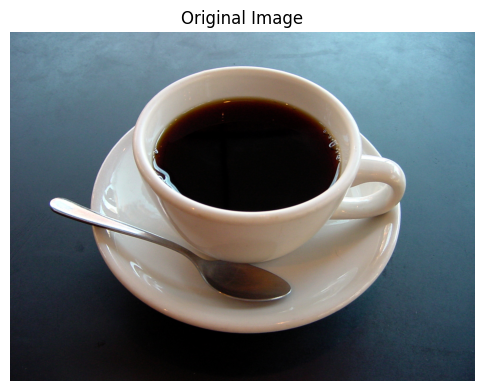

In [9]:
# TODO: Display the original image with matplotlib

plt.figure(figsize=(6,6))
plt.imshow(image_rgb)
plt.title('Original Image')
plt.axis('off')
plt.show()

**TASK 2: Edge Detection Using the Canny Algorithm**

**Objective:** Convert the image to grayscale and apply edge detection to highlight boundaries.

**Instructions:**

1. Convert the loaded image to grayscale.

2. Apply the Canny algorithm with appropriate threshold values.

3. Display the edge-detected output.

**Suggested Starter Snippet:**

In [10]:
#python
# Starter snippet for Task 2: Edge Detection using the Canny Algorithm
# TODO: Convert the image to grayscale using cv2.cvtColor
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)



In [11]:
# TODO: Apply the Canny edge detector (use threshold values 100 and 200)

# - The parameters threshold1 and threshold2 (100 and 200) control the sensitivity.
# - Lower thresholds capture more edges but may include noise; higher thresholds provide cleaner edges.
edges = cv2.Canny(gray, threshold1=100, threshold2=200)


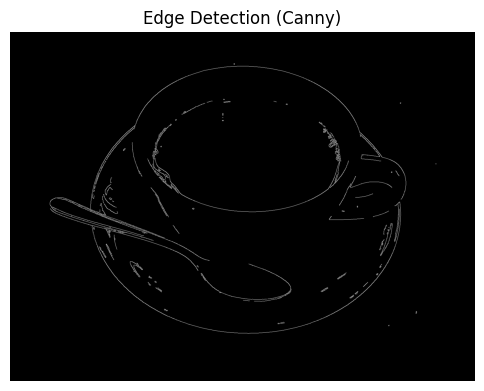

In [12]:
# TODO: Display the edge-detected image
plt.figure(figsize=(6,6))
plt.imshow(edges, cmap='gray')
plt.title('Edge Detection (Canny)')
plt.axis('off')
plt.show()

**TASK 3: Plot a Histogram of Pixel Intensities**

**Objective**: Compute and plot a histogram of pixel intensities for the grayscale image.

**Instructions**:

1. Use OpenCV’s calcHist function to compute the histogram.

2. Plot the histogram using matplotlib to show the distribution of pixel intensities from 0 to 255.

**Suggested Starter Snippet:**

In [13]:
#python
# Starter snippet for Task 3: Plot a Histogram of Pixel Intensities
# TODO: Compute the histogram using cv2.calcHist
hist = cv2.calcHist([gray], channels=[0], mask=None, histSize=[256], ranges=[0,256])



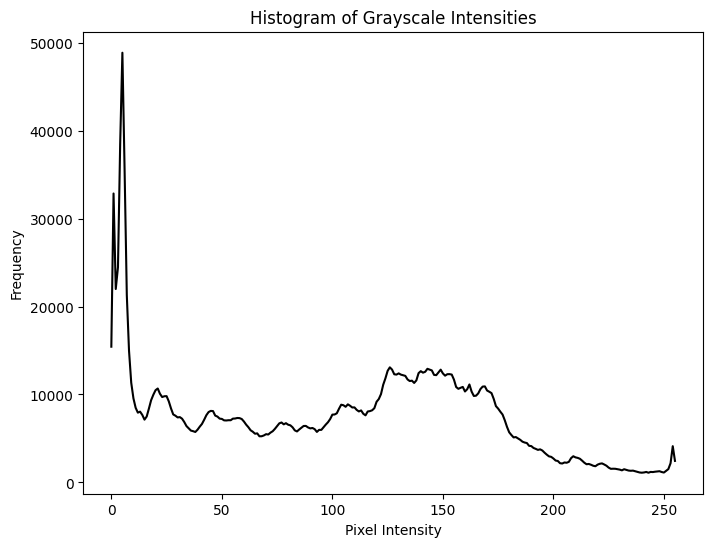

In [14]:
# TODO: Plot the histogram with matplotlib

plt.figure(figsize=(8,6))
plt.plot(hist, color='black')
plt.title("Histogram of Grayscale Intensities")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.show()

**TASK 4: Extract and Visualize Feature Maps Using a Simple CNN**

**Objective**: Build a simple CNN to extract feature maps from the image and visualize them in a grid.

**Instructions:**

1. Preprocess the image for TensorFlow by converting it to float32, normalizing it, and expanding its dimensions.

2. Build a simple CNN model containing one convolutional layer with 8 filters (3×3 kernel, ReLU activation, "same" padding).

3. Run the model to obtain feature maps.

4. Visualize the feature maps in a grid layout.

**Suggested Starter Snippet:**

In [15]:
#python
# Starter snippet for Task 4: Extract and Visualize Feature Maps Using a Simple CNN
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D


In [16]:

# TODO: Preprocess the image for the CNN: normalize and add a batch dimension
input_img = image_rgb.astype('float32') / 255.0
input_img = np.expand_dims(input_img, axis=0)  # Expected shape: (1, height, width, 3)


In [17]:

# TODO: Build a simple CNN model with one convolutional layer

# - The input layer takes the shape of our preprocessed image.
# - The convolutional layer applies 8 filters with a 3x3 kernel, using ReLU activation.
# - Padding is set to "same" to ensure that the output feature maps have the same spatial dimensions as the input.
input_layer = Input(shape=input_img.shape[1:])  # Exclude the batch dimension.
conv_layer = Conv2D(filters=8, kernel_size=(3,3), activation='relu', padding='same')(input_layer)
model = Model(inputs=input_layer, outputs=conv_layer)

In [18]:

# TODO: Pass the preprocessed image through the CNN to obtain the feature maps


# Explanation:
# This simple CNN applies 8 different convolutional filters to the image, thereby generating 8 feature maps.
# These feature maps highlight various aspects, such as edges and textures, learned from the image.

# Pass the image through the CNN to obtain the feature maps.
feature_maps = model.predict(input_img)
# Remove the batch dimension for visualization. The resulting shape is (height, width, 8).
feature_maps = feature_maps[0]



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step


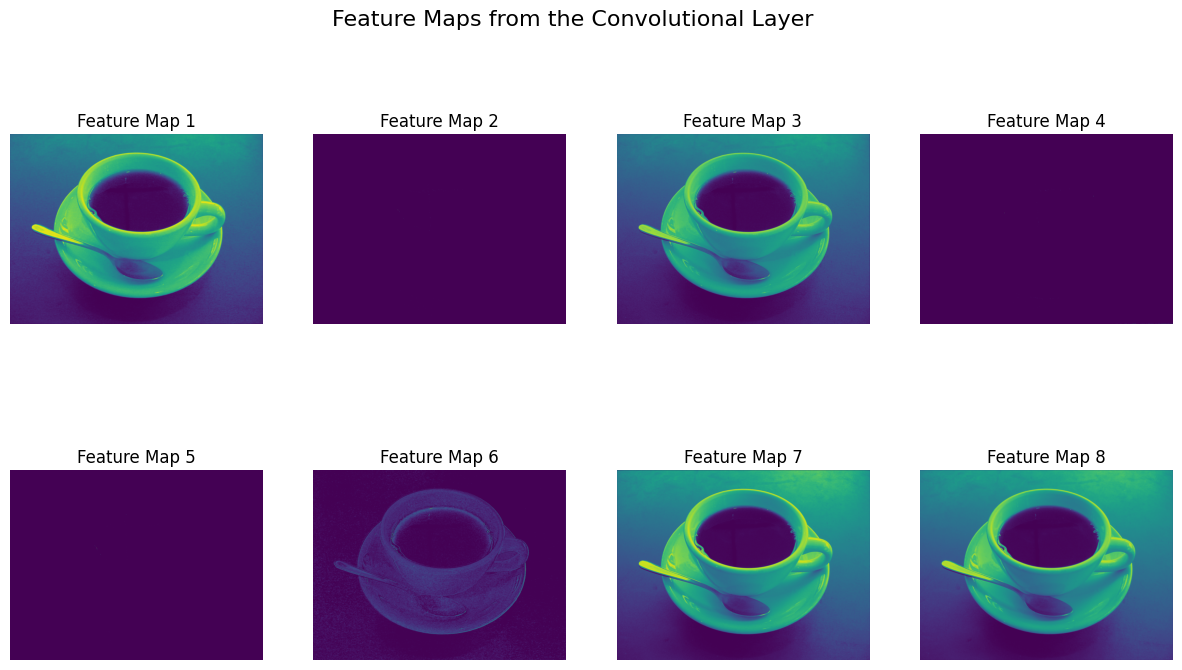

In [19]:

# TODO: Visualize each of the 8 feature maps in a grid (2 rows)

# - The results are arranged in a grid format with two rows.
num_filters = feature_maps.shape[-1]
plt.figure(figsize=(15,8))
for i in range(num_filters):
    plt.subplot(2, num_filters // 2, i+1)
    plt.imshow(feature_maps[:,:,i], cmap='viridis')
    plt.title(f'Feature Map {i+1}')
    plt.axis('off')
plt.suptitle("Feature Maps from the Convolutional Layer", fontsize=16)
plt.show()

#results: comment on why some of the maps look solid color or more blank

**TASK 5. Documentation and Submission**

1. **Documentation**: Ensure that your Colab notebook is well-documented. Include comments in each code cell explaining what each section of code is doing.
2. **File Submission**: When you have completed the assignment, save your Google Colab notebook as a .ipynb file and upload it to Brightspace as your assignment submission. (Example SmithMod03.ipynb)

**The End. Thank you very much.**